In [47]:
!pip install -U diffusers

In [48]:
pip install -U diffusers transformers accelerate

In [49]:
import torch
from diffusers import DiffusionPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## Locally Downlaoding the Model

In [50]:
pipe_1 = DiffusionPipeline.from_pretrained("prompthero/openjourney", dtype=torch.bfloat16, device_map="cuda")
prompt = "Astronaut riding a horse, in old japanese samurai era battelfield, 8k"
image_1 = pipe_1(prompt).images[0]

Keyword arguments {'dtype': torch.bfloat16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--prompthero--openjourney/snapshots/f4572661b028c732b2b97c8fbdc32fa5db3afe03/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--prompthero--openjourney/snapshots/f4572661b028c732b2b97c8fbdc32fa5db3afe03/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

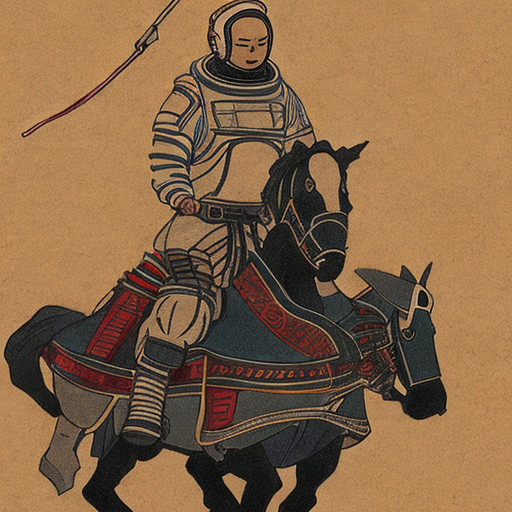

In [51]:
image_1

## Calling Inference API for models

### Model 1: `stabilityai`

In [62]:
import os
os.environ["HF_TOKEN"] = "MY_HF_KEY"

In [53]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="nscale",
    api_key=os.environ["HF_TOKEN"],
)

# output is a PIL.Image object
image = client.text_to_image(
    "Astronaut riding a horse",
    model="stabilityai/stable-diffusion-xl-base-1.0",
)

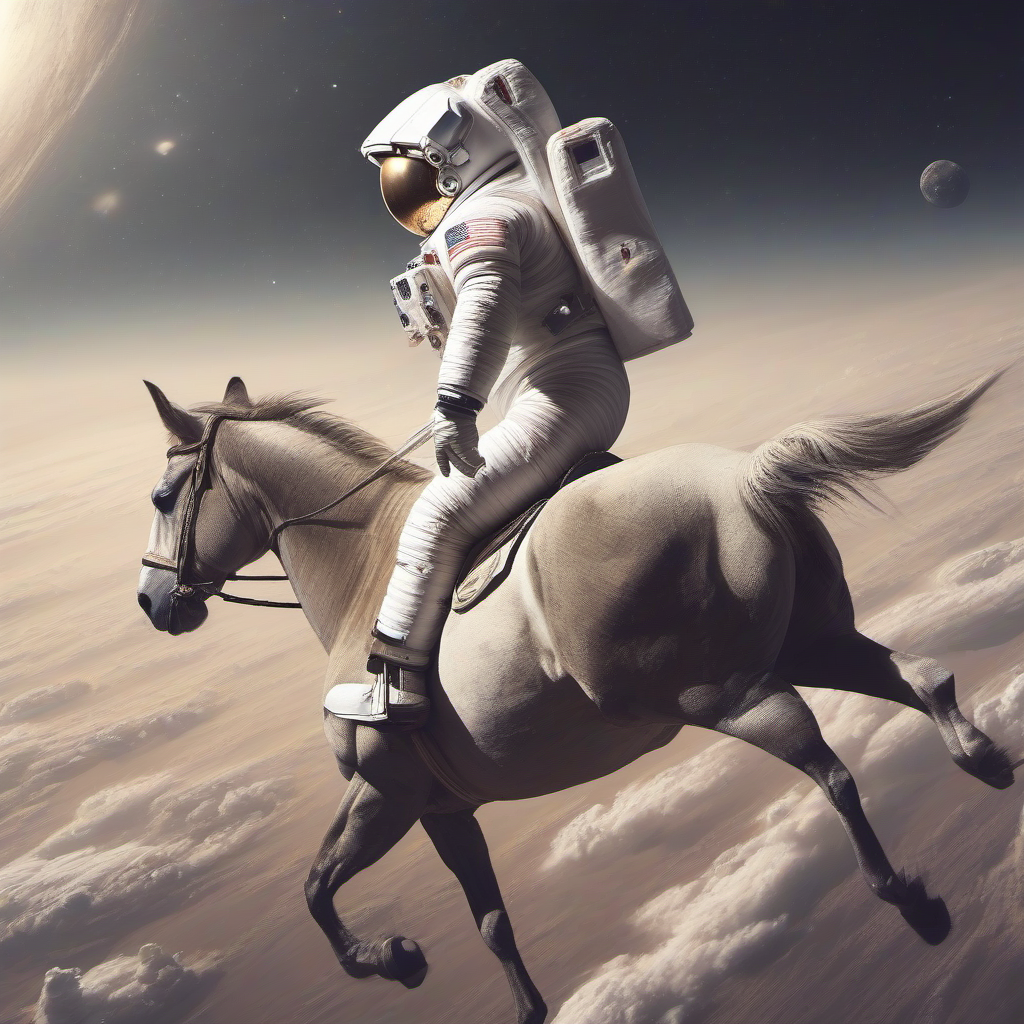

In [54]:
image

### Model 2: `black-forest-labs`

In [60]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="nscale",
    api_key=os.environ["HF_TOKEN"],
)

# output is a PIL.Image object
image = client.text_to_image(
    "Astronaut riding a horse, in Japan cherry blossom",
    model="black-forest-labs/FLUX.1-schnell",
)

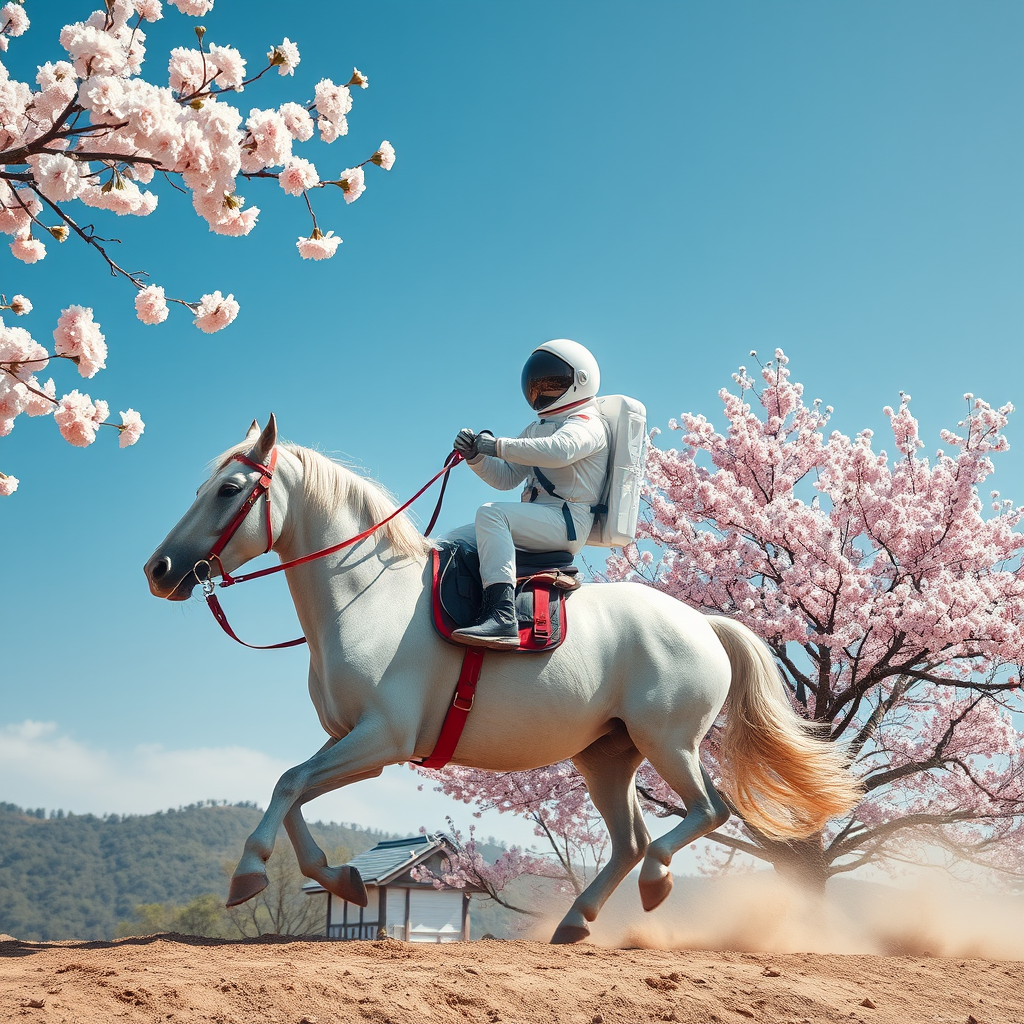

In [61]:
image

### Model 3: `ByteDance`

In [57]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="replicate",
    api_key=os.environ["HF_TOKEN"],
)

# output is a PIL.Image object
image = client.text_to_image(
    "Samurai wathcing over an army in distance from a cliff, getting ready for a battle.",
    model="ByteDance/SDXL-Lightning",
)

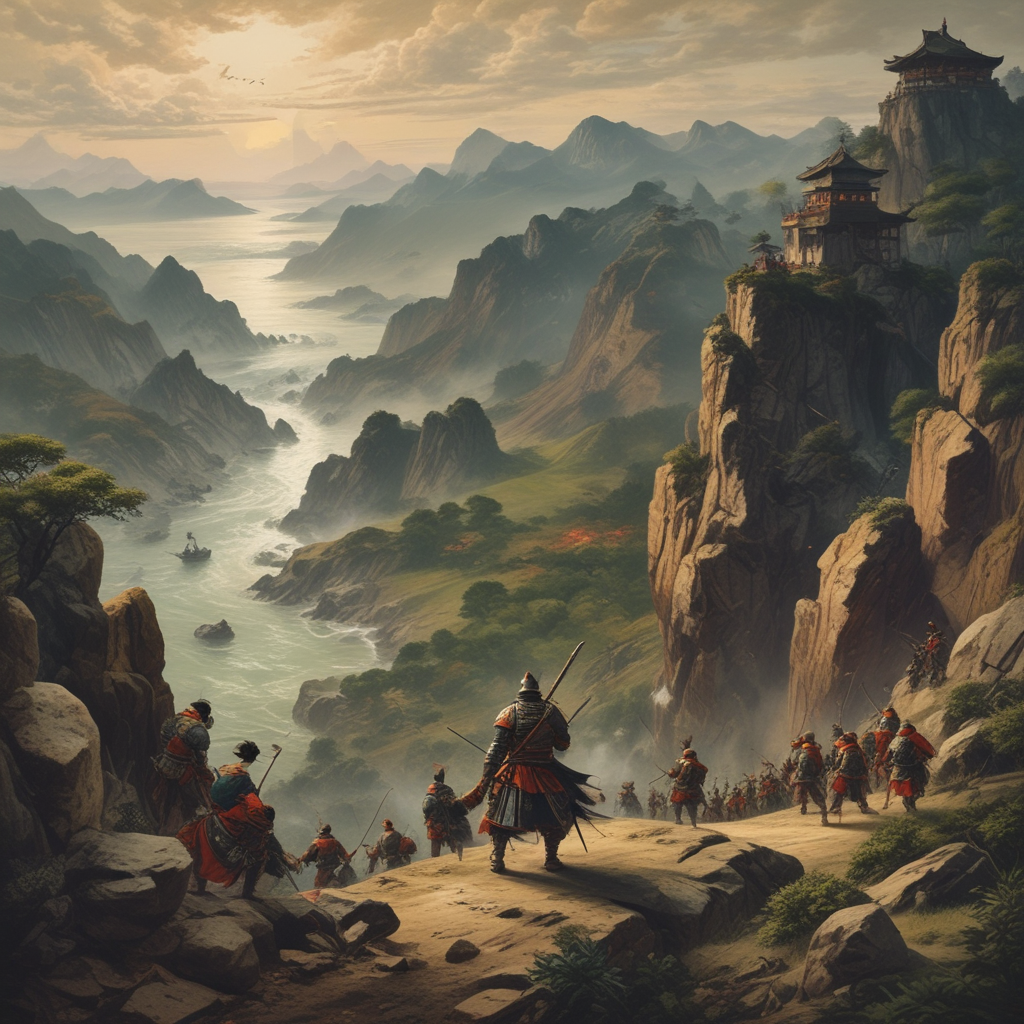

In [58]:
image

### Errors

In [59]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="fal-ai",
    api_key=os.environ["HF_TOKEN"],
)

# output is a PIL.Image object
image = client.text_to_image(
    "Astronaut riding a horse",
    model="Daverrrr75/Qwen-Remove-Clothing",
)

HfHubHTTPError: Client error '402 Payment Required' for url 'https://router.huggingface.co/fal-ai/fal-ai/qwen-image' (Request ID: Root=1-698a2220-01ef487067fb7dde075b4648;9dd7607c-aec2-4cdb-81bc-78a967d40bb6)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

Pre-paid credits are required to use provider fal-ai. Add pre-paid credits to your account to start using fal-ai.